In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import gc
import pickle

import sys
from pathlib import Path

# Add parent directory to path
sys.path.append(str(Path.cwd().parent))

from models import KDV

cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

CUDA available: True


In [2]:
INIT_PARAMS = dict(
                num_solitons             = 2,
                n_hidden_layers          = 7, 
                n_neurons_per_layer      = 62, 
                activation               = nn.Tanh,
                seed                     = 72, 
                verbose                  = True,
            )
            
TRAIN_PARAMS_CONS = dict(
                adam_epochs              = 1000,
                verbose_step             = 100,
                n_collocation            = 100000, 
                n_initial                = 30000,  
                n_boundary               = 10000,
                n_momentum               = 0, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
                n_energy                 = 30,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
                n_hamiltonian            = 30,
                adam_lr                  = 1e-3,   
                lbfgs_lr                 = 2.0,    
                lbfgs_history_size       = 295, 
                lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
                adaptive_sampling        = False,   
                logging                  = False, #new parameter, stops loss logging bottleneck for quick training (no loss history)
                verbose                  = True,
            )
TRAIN_WEIGHTS_CONS = dict[str, float]( #seperated out from the train params
                w_ic                     = 10.0,    
                w_bc                     = 1.0,    
                w_pde                    = 100.0,
                w_momentum               = 0,
                w_energy                 = 1.0,
                w_hamiltonian            = 2.5,
            )

TRAIN_PARAMS_ADAPT = dict(
                adam_epochs              = 1000,
                verbose_step             = 100,
                n_collocation            = 100000, 
                n_initial                = 30000,  
                n_boundary               = 10000,
                n_momentum               = 0, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
                n_energy                 = 0,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
                n_hamiltonian            = 0,
                adam_lr                  = 1e-3,   
                lbfgs_lr                 = 2.0,    
                lbfgs_history_size       = 295, 
                lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
                adaptive_sampling        = True,   
                logging                  = True, #new parameter, stops loss logging bottleneck for quick training (no loss history)
                verbose                  = True,
            )

TRAIN_WEIGHTS_ADAPT = dict[str, float]( #seperated out from the train params
                w_ic                     = 10.0,    
                w_bc                     = 1.0,    
                w_pde                    = 100.0,
                w_momentum               = 0.0,
                w_energy                 = 0.0,
                w_hamiltonian            = 0.0,
            )

TRAIN_PARAMS_BASE = dict(
                adam_epochs              = 1000,
                verbose_step             = 100,
                n_collocation            = 100000, 
                n_initial                = 30000,  
                n_boundary               = 10000,
                n_momentum               = 0, # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_momentum)
                n_energy                 = 0,   # only the t component, the x domain resolution will be the same as n_initial (nx * nt) = (n_initial * n_energy)
                n_hamiltonian            = 0,
                adam_lr                  = 1e-3,   
                lbfgs_lr                 = 2.0,    
                lbfgs_history_size       = 295, 
                lbfgs_version            = 'test', #test is 'old' and anything else will default to a modified version of 'new' from legacy
                adaptive_sampling        = False,   
                logging                  = True, #new parameter, stops loss logging bottleneck for quick training (no loss history)
                verbose                  = True,
            )

TRAIN_WEIGHTS_BASE = dict[str, float]( #seperated out from the train params
                w_ic                     = 10.0,    
                w_bc                     = 1.0,    
                w_pde                    = 100.0,
                w_momentum               = 0.0,
                w_energy                 = 0.0,
                w_hamiltonian            = 0.0,
            )

In [ ]:
del model_base
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [3]:
model_cons = KDV(INIT_PARAMS)
training_stats, _ = model_cons.fit(TRAIN_PARAMS_CONS, TRAIN_WEIGHTS_CONS)
error_stats = model_cons.test(nx = 1000, nt=1000, error_type='absolute-normalized')

Using device: cuda
Weighted losses [start]: IC=6.912e-01 | BC=1.726e-01 | PDE=3.511e-01
Starting Adam optimization...
[gpu mem] train start               alloc 11310.6 MB  reserved 11396.0 MB  peak 11310.6 MB
Adam - Epoch 0/1000, Total Loss: 7.109516e+01
Adam - Epoch 100/1000, Total Loss: 3.906576e-01
Adam - Epoch 200/1000, Total Loss: 2.495833e-01
Adam - Epoch 300/1000, Total Loss: 1.968828e-01
Adam - Epoch 400/1000, Total Loss: 1.619296e-01
Adam - Epoch 500/1000, Total Loss: 1.335522e-01
Adam - Epoch 600/1000, Total Loss: 1.245231e-01
Adam - Epoch 700/1000, Total Loss: 1.213616e-01
Adam - Epoch 800/1000, Total Loss: 1.187224e-01
Adam - Epoch 900/1000, Total Loss: 1.162685e-01
Adam - Epoch 999/1000, Total Loss: 1.139488e-01
[gpu mem] after Adam                alloc    20.7 MB  reserved 22726.0 MB  peak 22620.3 MB

Starting L-BFGS optimization...


/home/jairdan/soliton-pinns/models/kdv/loss.py:232: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  losses['total'].append(float(total_loss))


L-BFGS - Iteration -900, Total Loss: 3.851341e-02
L-BFGS - Iteration -800, Total Loss: 7.051686e-03
L-BFGS - Iteration -700, Total Loss: 3.472702e-03
L-BFGS - Iteration -600, Total Loss: 2.234371e-03
L-BFGS - Iteration -500, Total Loss: 1.416167e-03
L-BFGS - Iteration -400, Total Loss: 1.016281e-03
L-BFGS - Iteration -300, Total Loss: 7.387711e-04
L-BFGS - Iteration -200, Total Loss: 5.581552e-04
L-BFGS - Iteration -100, Total Loss: 4.273004e-04
L-BFGS - Iteration 0, Total Loss: 3.087211e-04
L-BFGS - Iteration 100, Total Loss: 2.547919e-04
L-BFGS - Iteration 200, Total Loss: 2.065924e-04
L-BFGS - Iteration 300, Total Loss: 1.571365e-04
L-BFGS - Iteration 400, Total Loss: 1.346981e-04
L-BFGS - Iteration 500, Total Loss: 1.165141e-04
L-BFGS - Iteration 600, Total Loss: 9.964799e-05
L-BFGS - Iteration 700, Total Loss: 8.725432e-05
L-BFGS - Iteration 800, Total Loss: 7.923275e-05
L-BFGS - Iteration 900, Total Loss: 6.889118e-05
L-BFGS - Iteration 1000, Total Loss: 6.232102e-05
L-BFGS - Ite

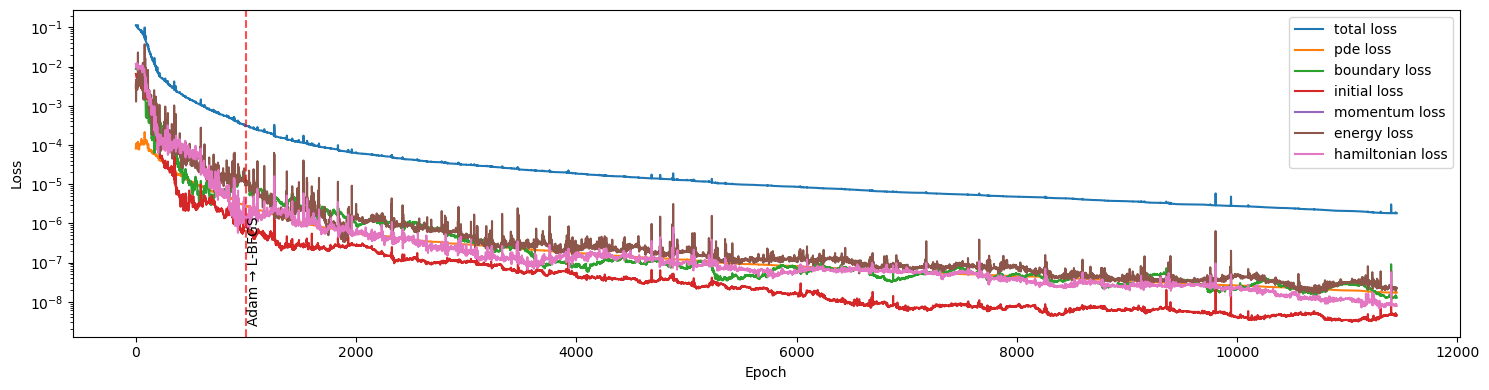

In [4]:
fig4 = model_cons.plot_losses(training_stats)

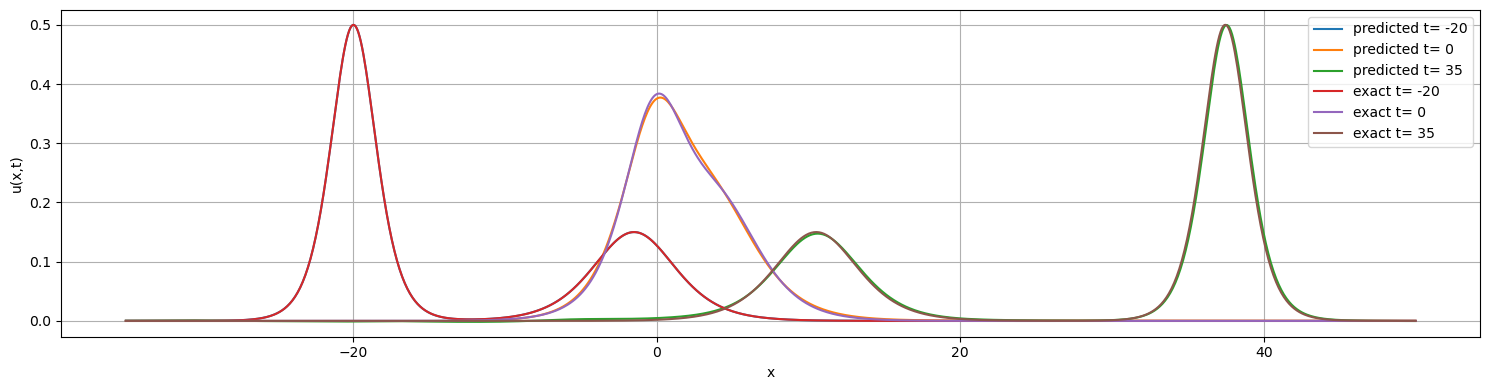

In [7]:
fig5 = model_cons.plot_profiles(t_values=[-20, 0, 35], which=('predicted', 'exact'))

absolute-normalized error metrics:
Mean: 2.450142e-03
Maximum: 3.522208e-02


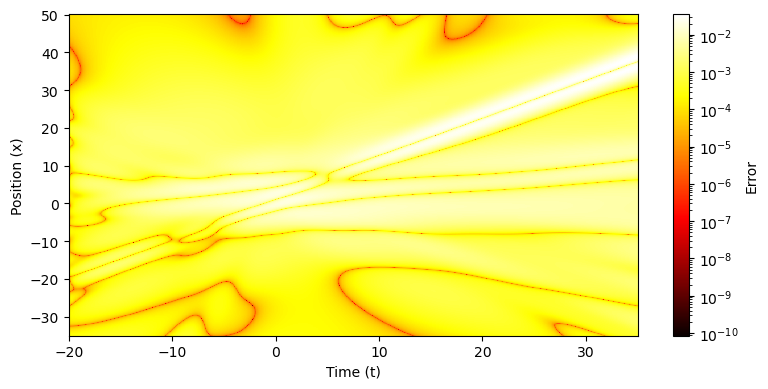

In [6]:
fig6 = model_cons.plot_heatmap()

In [8]:
model_adapt = KDV(INIT_PARAMS)
training_stats, _ = model_adapt.fit(TRAIN_PARAMS_ADAPT, TRAIN_WEIGHTS_ADAPT)
error_stats = model_adapt.test(nx = 1000, nt=1000, error_type='absolute-normalized')

Using device: cuda
Weighted losses [start]: IC=6.912e-01 | BC=1.726e-01 | PDE=3.511e-01
Starting Adam optimization...
[gpu mem] train start               alloc  4469.2 MB  reserved  4550.0 MB  peak  4469.2 MB
Adam - Epoch 0/1000, Total Loss: 1.214919e+00
Adam - Epoch 100/1000, Total Loss: 3.954471e-02
Adam - Epoch 200/1000, Total Loss: 2.049086e-02
Adam - Epoch 300/1000, Total Loss: 8.631360e-03
Adam - Epoch 400/1000, Total Loss: 4.154215e-03
Adam - Epoch 500/1000, Total Loss: 1.798875e-03
Adam - Epoch 600/1000, Total Loss: 1.145958e-03
Adam - Epoch 700/1000, Total Loss: 9.817784e-04
Adam - Epoch 800/1000, Total Loss: 6.638333e-04
Adam - Epoch 900/1000, Total Loss: 5.387327e-04
Adam - Epoch 999/1000, Total Loss: 4.989587e-04
[gpu mem] after Adam                alloc    21.9 MB  reserved  8990.0 MB  peak  8967.8 MB
Performing adaptive sampling...
Collocation points from 100000 -> 200000

Starting L-BFGS optimization...
L-BFGS - Iteration 100, Total Loss: 4.528043e-04
L-BFGS - Iteration 

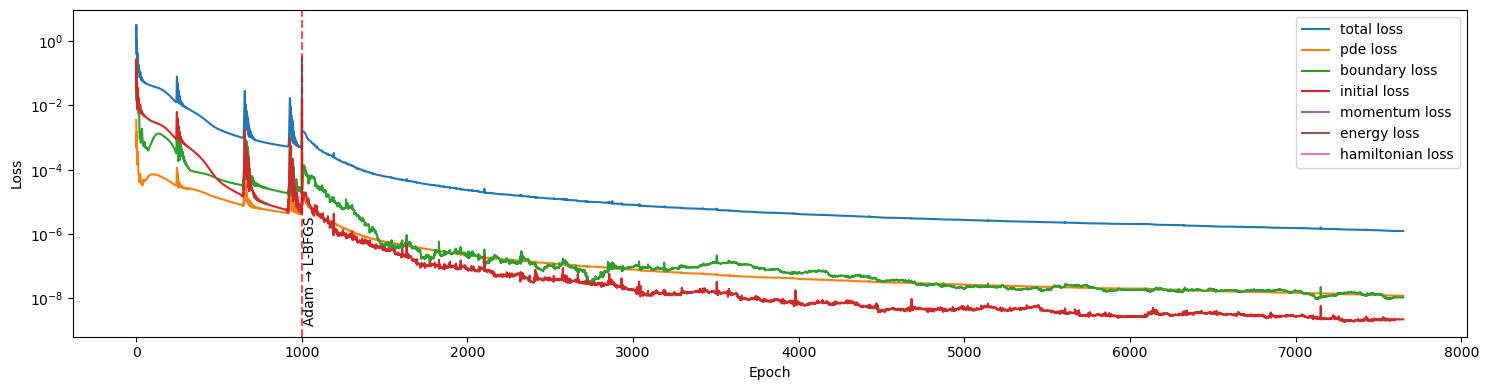

In [12]:
fig7 = model_adapt.plot_losses(training_stats)

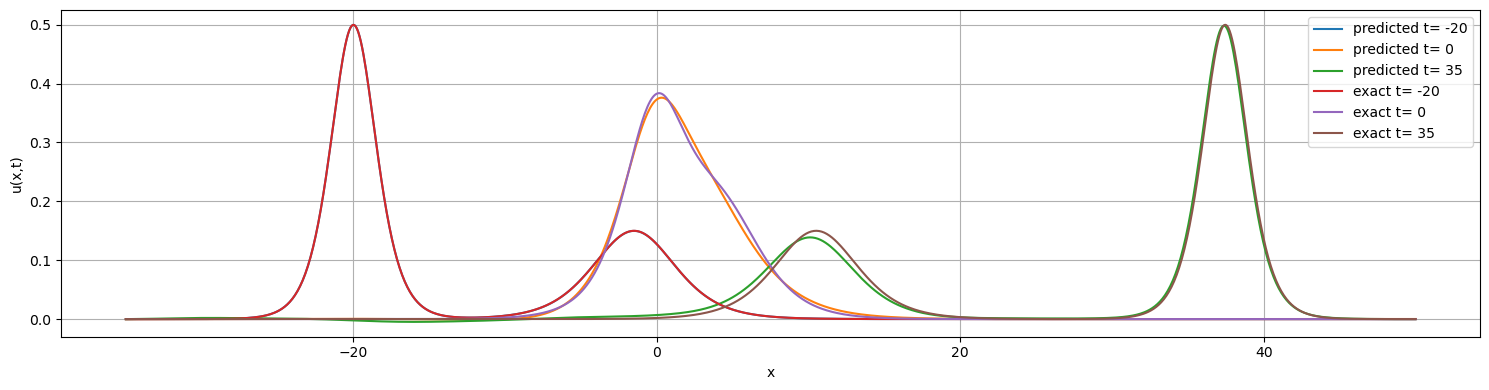

In [13]:
fig8 = model_adapt.plot_profiles(t_values=[-20, 0, 35], which=('predicted', 'exact'))

absolute-normalized error metrics:
Mean: 4.293457e-03
Maximum: 3.523269e-02


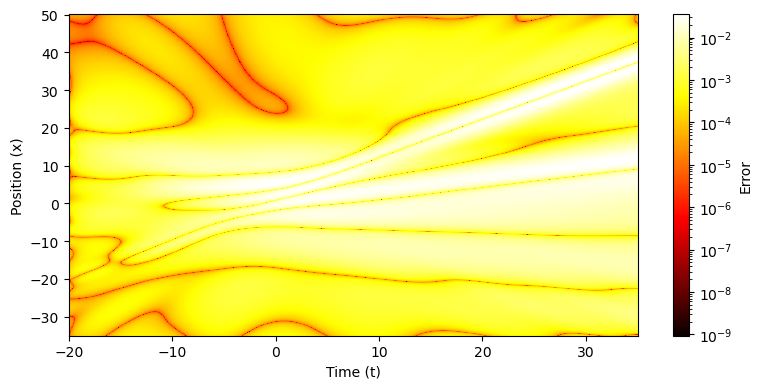

In [14]:
fig9 = model_adapt.plot_heatmap()